In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('indian_names.txt', 'r').read().lower().splitlines()
words[:8]

['aaban',
 'aabharan',
 'aabhas',
 'aabhat',
 'aabheer',
 'abheer',
 'aabher',
 'aabi']

In [3]:
len(words)

53982

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([390591, 3]) torch.Size([390591])
torch.Size([48694, 3]) torch.Size([48694])
torch.Size([48789, 3]) torch.Size([48789])


In [6]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
#we multiply ariables with some values to make the logits near 0 so we dont get false confidence and random loss

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) #* 0.2
#b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [7]:
#The segment on initialization scaling (0:27:53) explains the mathematical need to keep neural network activations 
#within a healthy, non-extreme range as data passes through layers.

#The Problem of Variance Expansion: Without proper scaling, simply multiplying inputs by randomly initialized 
                                    #weights causes the variance of the activations to grow or shrink drastically as they pass through layers. 
                                    #This leads to activations that either explode or vanish, preventing effective learning.
#The Solution (Kaiming Init): To keep the activation distribution stable (specifically, to maintain unit Gaussian statistics), 
                            #the weights should be initialized by scaling them by the square root of the fan-in (the number of input connections). 
                            #This ensures that the output standard deviation remains near 1.0 .
#The Role of Nonlinearity (Gain): Because activation functions like tanh are "contractive" (they squash values into a specific range), 
                                #they reduce the variance of the signal. To counteract this, researchers introduce a gain factor. 
                                #For tanh, the recommended gain is, which boosts the weights just enough to compensate for the 
                                #squashing effect and maintain healthy activation flow through deep networks (0:35:10).

tensor(-0.0188) tensor(1.0022)
tensor(-0.0012) tensor(0.9719)


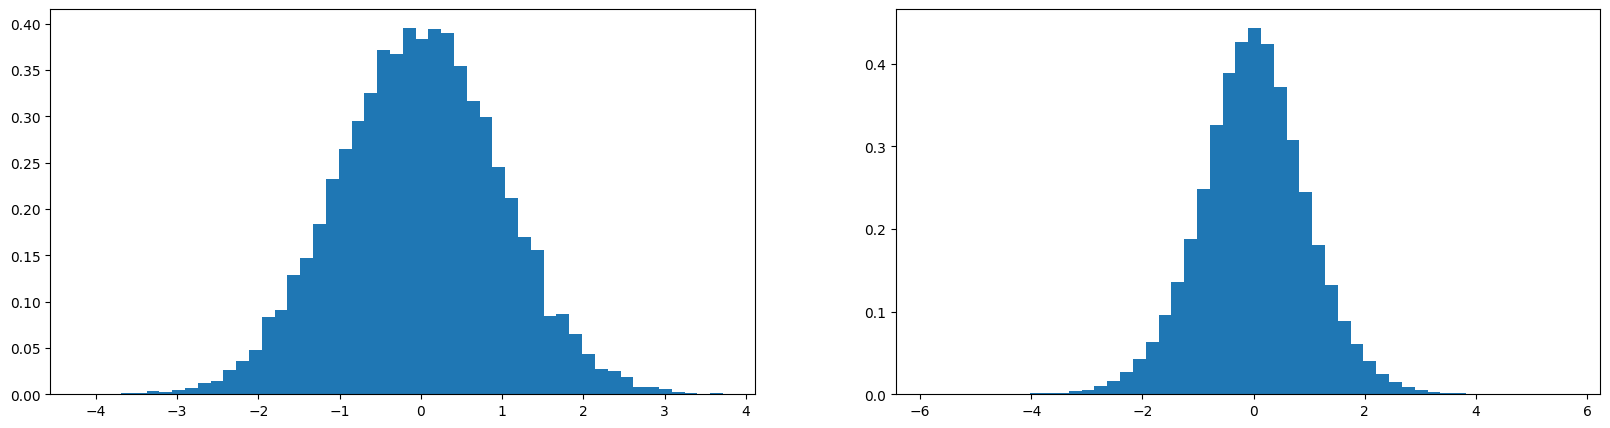

In [8]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);


In [9]:
#The second problem discussed (0:12:59) relates to the saturation of the tanh activation function. 
#After fixing the initial loss (the hockey stick problem), a deeper issue remains regarding the health of the hidden states (H).

#The Issue: When you inspect the distribution of values within the hidden layer H, many of the elements end up being exactly 1 or -1 (13:31).

#Why this happens: The tanh function is a "squashing" function that maps any input value into the range of 
                    #If the inputs (pre-activations) to tanh are too large, the output is forced into the extreme tails of the function, 
                    #where it becomes flat (saturated).

#The Consequence: In these saturated regions, the gradient of tanh is near zero. During backpropagation, 
                #this means the gradient signal effectively dies, preventing the network from updating those weights effectively.
                #This makes the hidden layer inactive and hinders learning.

#To address this, the video explains that you need to carefully control the scale of the weights at initialization 
#(using techniques like Kaiming init) to ensure the pre-activations remain in the active range of the tanh function .


In [10]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y


    
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  
    
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
  # BatchNorm layer
  # -------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # -------------------------------------------------------------
  
    
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function



  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.2669
  10000/ 200000: 2.1642
  20000/ 200000: 1.8201
  30000/ 200000: 1.9720
  40000/ 200000: 2.1636
  50000/ 200000: 2.3132
  60000/ 200000: 2.0735
  70000/ 200000: 2.3020
  80000/ 200000: 2.1193
  90000/ 200000: 2.1518
 100000/ 200000: 1.7698
 110000/ 200000: 1.9745
 120000/ 200000: 2.3668
 130000/ 200000: 1.9336
 140000/ 200000: 2.3396
 150000/ 200000: 1.5294
 160000/ 200000: 1.4367
 170000/ 200000: 1.4523
 180000/ 200000: 1.8953
 190000/ 200000: 2.0062


In [11]:
# WHAT IS BATCH NORMALIZATION (BN)?

# Think of it as a tool that "cleans up" data inside your neural network.
# 
# As data flows through deep layers, the numbers can get wildly large or incredibly small. This messes up the training process.
# Batch Normalization steps in to keep these numbers in a stable,  predictable range so the network can learn much faster.
#
# THE 3-STEP IMPLEMENTATION
#
# STEP 1: FIND THE AVERAGE (MEAN) AND VARIANCE
# --------------------------------------------
# Look at the current batch of data going through a layer.
# - Calculate the average (mean) value for each feature/neuron.
# - Calculate the variance (how spread out the numbers are).
#
# STEP 2: STANDARDIZE THE NUMBERS
# --------------------------------
# - Take every number, subtract the average, and divide by the spread.
# - Add a tiny number (called "epsilon" or "eps") before dividing so you never accidentally divide by zero.
# - Result: Your data now has an average of 0 and a spread of 1.
#
# STEP 3: GIVE THE NETWORK FLEXIBILITY (SCALE & SHIFT)
# ----------------------------------------------------
# Forcing everything to have an average of 0 and spread of 1 can be too restrictive. The network might actually *need* different ranges.
# - Introduce two trainable parameters:     gain  Gamma (scale)     and      bias Beta (shift).
# - Multiply the data by Gamma and add Beta.
# - The network will automatically learn the best values for these during training, letting it "undo" the normalization if needed.
#
# IMPORTANT PRACTICAL TIPS
#
# 1. TRAINING VS. TESTING (INFERENCE)
# -----------------------------------
# - When training: You calculate the average and spread using the  current batch of data.
# - When testing/predicting: You might only feed the network one single image or text sample. You cannot calculate a batch average for it.
# - Solution: During training, keep a running tally (a moving average) of the mean and variance. Use this stored history during testing.
#
# 2. TURN OFF LINEAR/CONV BIAS
# ----------------------------
# - A standard Linear or Convolutional layer adds a "bias" (a shift).
# - But Batch Normalization's "Beta" parameter *also* shifts the numbers.
# - Therefore, a bias in the previous layer is completely useless.
# - Always set `bias=False` in the layer right before Batch Normalization to save memory and computation.


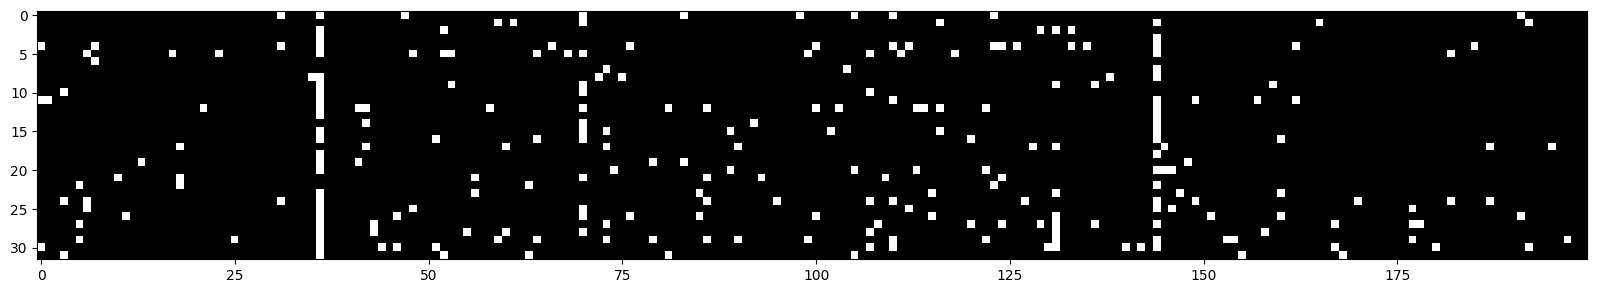

In [12]:
plt.figure(figsize = (20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

(array([349., 178., 149., 142., 122., 129., 110., 114., 120.,  95., 113.,
        101., 104.,  88.,  88., 102., 107., 120., 110., 118., 115., 111.,
        130., 135., 187., 192., 138., 137., 120., 111., 112., 107.,  92.,
         90., 100.,  83.,  81.,  97.,  94., 104., 100., 110., 111., 116.,
        121., 119., 139., 167., 186., 336.]),
 array([-9.99957025e-01, -9.59957931e-01, -9.19958837e-01, -8.79959743e-01,
        -8.39960649e-01, -7.99961555e-01, -7.59962461e-01, -7.19963367e-01,
        -6.79964273e-01, -6.39965179e-01, -5.99966085e-01, -5.59966991e-01,
        -5.19967897e-01, -4.79968803e-01, -4.39969709e-01, -3.99970615e-01,
        -3.59971521e-01, -3.19972427e-01, -2.79973333e-01, -2.39974239e-01,
        -1.99975145e-01, -1.59976051e-01, -1.19976957e-01, -7.99778628e-02,
        -3.99787688e-02,  2.03251839e-05,  4.00194192e-02,  8.00185132e-02,
         1.20017607e-01,  1.60016701e-01,  2.00015795e-01,  2.40014889e-01,
         2.80013983e-01,  3.20013077e-01,  3.60012

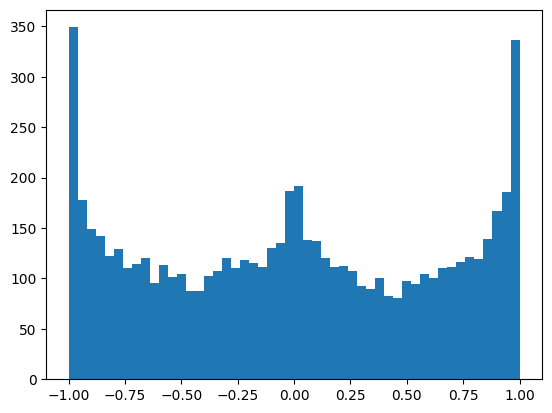

In [13]:
plt.hist(h.view(-1).tolist(), 50)

In [13]:
logits[0]

tensor([-4.2641,  6.0348, -0.1530, -2.5582, -0.4385,  4.5843, -2.6986, -1.4436,
         0.1067,  4.9519, -1.7246, -0.5415, -0.7286,  0.1639, -0.2998,  4.5798,
        -1.4943, -4.0150,  2.9538,  0.1530, -0.8496,  4.5359, -1.3218, -2.1769,
        -3.9442,  2.7439, -2.2199], grad_fn=<SelectBackward0>)

In [14]:
#Why Logits Matter (0:04:19)
#When a network is initialized with random weights, the logits (the raw output values before the softmax function) 
#can become extremely large. This causes the neural network to produce probability distributions that are confidently wrong, 
#resulting in a very high initial loss. By ensuring logits are near zero at initialization, the network starts with a 
#uniform probability distribution, which reflects a state of no initial bias and leads to a much lower, expected loss value.

#Practical Implementation
#To achieve this, the video recommends:

#Avoiding large random biases: Setting biases to zero at initialization.
#Scaling down weights: Multiplying weight matrices by a small factor (like 0.01 or 0.1) prevents logits from taking on extreme values.

#This adjustment eliminates the "hockey stick" loss curve, where the model spends unnecessary 
#iterations just shrinking the weight values before it can actually begin learning effectively .



In [ ]:
# 4-dimensional example of the issue
#logits = torch.tensor([-10.0, 5.0, 0.0, 0.0])
logits = torch.randn(4) * 10
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits, probs, loss


In [11]:
-torch.tensor(1/3.2669).log()

tensor(1.1838)

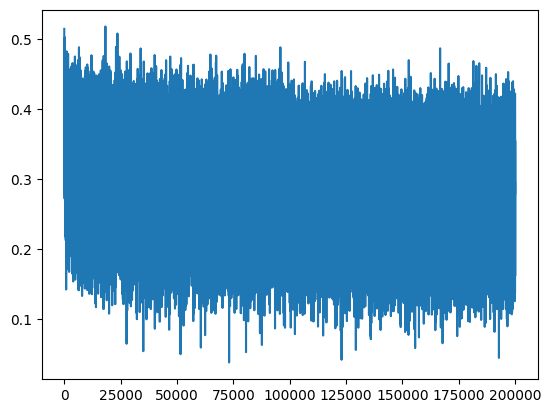

In [14]:
plt.plot(lossi)

In [15]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)

In [16]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9065102338790894
val 1.927498459815979


In [17]:
# summarry and pytorchification -----------------------------------

In [18]:
# Let's train a deeper network
# The classes we create here are the same API as nn.Module in PyTorch

class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd),            generator=g)
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]
# layers = [
#   Linear(n_embd * block_size, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].gamma *= 0.1
  #layers[-1].weight *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 1.0 #5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

47024


In [19]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 1000:
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.2940


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.91%
layer 5 (      Tanh): mean +0.00, std 0.65, saturated: 2.09%
layer 8 (      Tanh): mean -0.00, std 0.65, saturated: 1.97%
layer 11 (      Tanh): mean -0.00, std 0.65, saturated: 1.72%
layer 14 (      Tanh): mean -0.00, std 0.65, saturated: 1.53%


C:\Users\Arnav Verma\AppData\Local\Temp\ipykernel_33300\1397477801.py:7: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))


Text(0.5, 1.0, 'activation distribution')

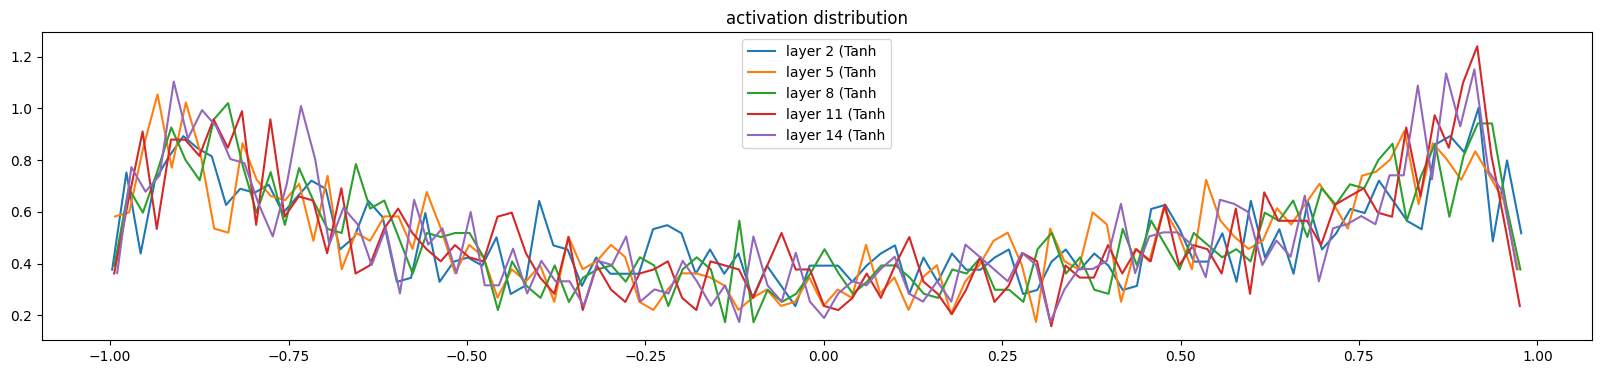

In [20]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 3.059196e-03
layer 5 (      Tanh): mean +0.000000, std 2.508509e-03
layer 8 (      Tanh): mean -0.000000, std 2.414436e-03
layer 11 (      Tanh): mean -0.000000, std 2.123724e-03
layer 14 (      Tanh): mean -0.000000, std 2.174891e-03


Text(0.5, 1.0, 'gradient distribution')

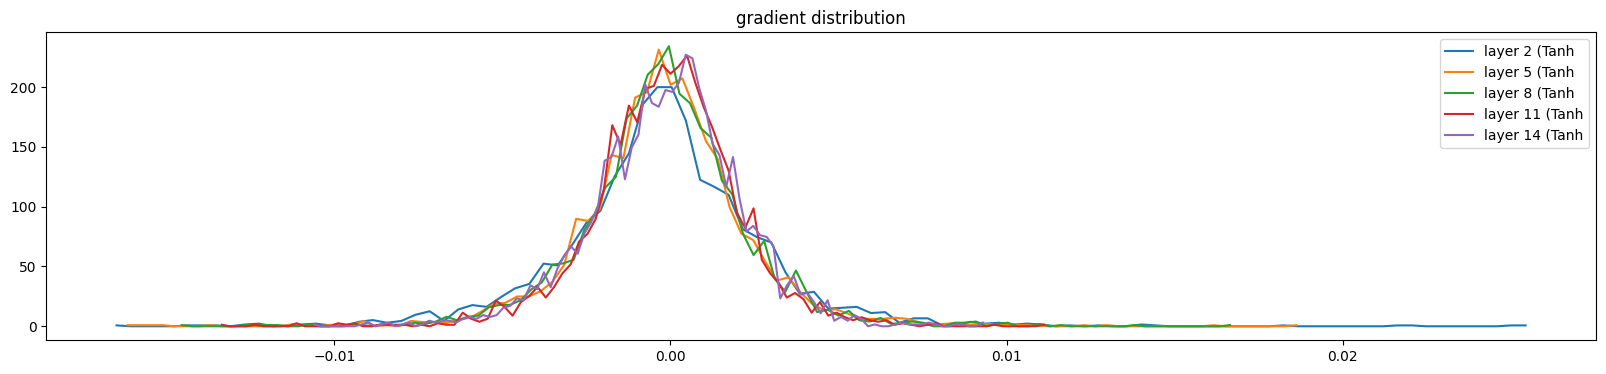

In [21]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000000 | std 1.103053e-02 | grad:data ratio 1.101926e-02
weight  (30, 100) | mean +0.000192 | std 1.232847e-02 | grad:data ratio 6.507087e-02
weight (100, 100) | mean +0.000234 | std 9.529073e-03 | grad:data ratio 9.310687e-02
weight (100, 100) | mean +0.000061 | std 8.107445e-03 | grad:data ratio 7.906679e-02
weight (100, 100) | mean -0.000060 | std 7.790400e-03 | grad:data ratio 7.645974e-02
weight (100, 100) | mean +0.000103 | std 6.780898e-03 | grad:data ratio 6.661725e-02
weight  (100, 27) | mean -0.000198 | std 1.476338e-02 | grad:data ratio 1.412020e-01


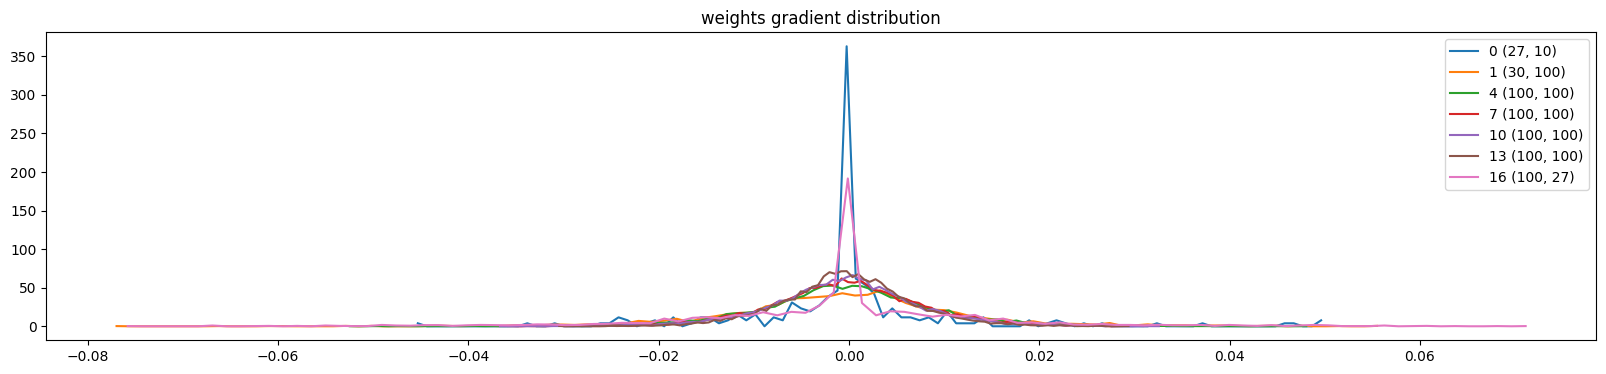

In [22]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

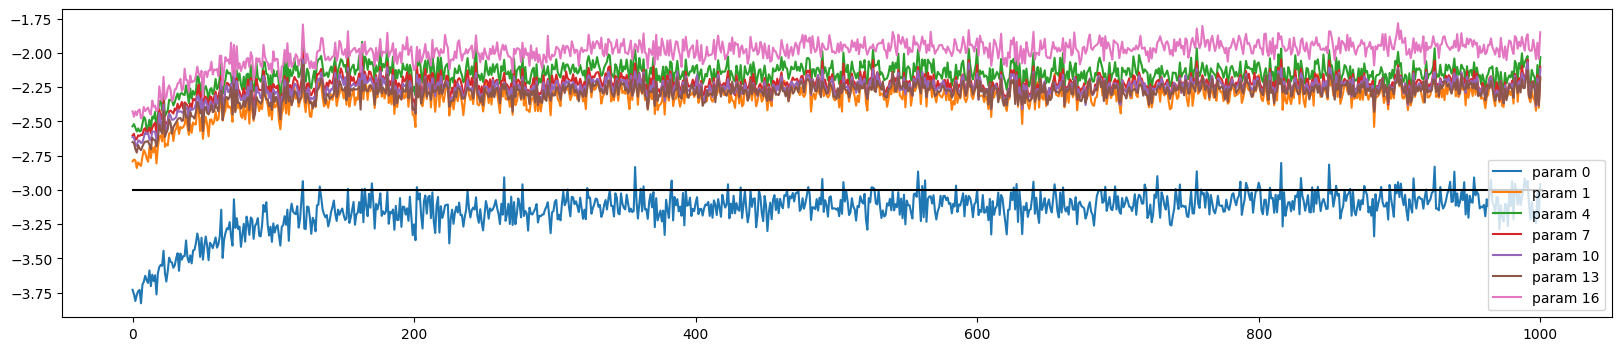

In [23]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [24]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.1710102558135986
val 2.1714155673980713


In [25]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

narpaixaar.
harithimrshiththan.
cansh.
jarhuthanpesarthirqhiunesharatchaiivdhana.
gpuham.
poiniqshan.
shoinesh.
vabi.
waathugijaryxi.
jineshinudh.
sa.
epoi.
kata.
feyara.
varas.
bharhisya.
paqqoaozerjhojhan.
kairan.
dep.
sadhuuoyeoessi.
